In [253]:
import numpy as np
import pandas as pd
import openmatrix as omx
from pathlib import Path
from dbfread import DBF
import copy
from datetime import datetime
import os


In [254]:
# import global TDM functions
import sys

sys.path.insert(0, "../Resources/2-Python/global-functions")
import BigQuery

client = BigQuery.getBigQueryClient_Confidential2023UtahHTS()


## Functions


In [255]:
# function used to load coefficients from the block file
def load_block_coefficients(file_path):
    coeffs = {}
    with open(file_path, "r") as f:
        for line in f:
            line = line.split(";")[0].strip()
            if not line or "=" not in line:
                continue
            name, val = line.split("=")
            name = name.strip().lower()
            val = float(val.strip())
            parts = name.split("_")
            seg = f"{parts[-2]}_{parts[-1]}"  # e.g., 0veh_lo
            param = "_".join(parts[:-2])  # e.g., intra, logsum
            if seg not in coeffs:
                coeffs[seg] = {}
            coeffs[seg][param] = val
    return coeffs


In [256]:
# function used to apply range-based masking for external zones
def apply_range_mask(mask_array, range_str):
    for r in range_str.split(","):
        if "-" in r:
            start, end = map(int, r.split("-"))
            # This correctly maps TAZ 3563 to Index 3562
            mask_array[start - 1 : end] = True
        else:
            mask_array[int(r) - 1] = True


In [257]:
# function to sum values in the household productions creation script
def sum_columns(hbw_productions, prefix_list, veh_suffixes):
    cols = []
    for prefix in prefix_list:
        for v in veh_suffixes:
            cols.append(f"P_{prefix}{v}")
    return hbw_productions[cols].sum(axis=1)


In [258]:
# calculate size term for utility equation (size of destination in terms of nubmer of opportunities)
def get_size_term(seg_coeffs, df_se_input):
    # total employment
    total_emp = df_se_input["TOTEMP"].values.astype(float).copy()

    # precision-safe replacement logic
    epsilon = 1e-6
    for emp_type, coeff_key in [
        ("RETEMP", "retail_emp"),
        ("INDEMP", "industrial_emp"),
        ("OTHEMP", "other_emp"),
    ]:
        coeff = seg_coeffs.get(coeff_key, 1.0)

        if abs(coeff - 1.0) > epsilon:
            raw_emp = df_se_input[emp_type].values
            total_emp += raw_emp * (coeff - 1.0)

    # Ignore the divide by zero warning, let Python evaluate log(0) as -inf
    with np.errstate(divide="ignore", invalid="ignore"):
        ln_size = np.log(total_emp)

    return ln_size


In [259]:
def export_run_for_dashboard(trips_data, df_se_full, run_name, file_name):
    """Rolls up the TAZ matrices to Large Districts and saves to a standalone CSV."""
    print(f"\n  -> Exporting '{run_name}' to CSV...")

    dist_lrg_array = df_se_full["DISTLRG"].values
    dist_records = []

    for seg, data in trips_data.items():
        # Melt the TAZ matrix
        df_taz = pd.DataFrame(data["trips"])
        df_taz["p_DistLrg"] = dist_lrg_array
        df_long = df_taz.melt(
            id_vars=["p_DistLrg"], var_name="a_taz", value_name="total_trips"
        )

        # Map a_taz index to a_DistLrg and group
        df_long["a_DistLrg"] = df_long["a_taz"].map(lambda x: dist_lrg_array[x])
        df_dist = df_long.groupby(["p_DistLrg", "a_DistLrg"], as_index=False)[
            "total_trips"
        ].sum()

        # Add identifiers
        df_dist["veh_inc"] = seg
        df_dist["Source"] = run_name
        dist_records.append(df_dist)

    df_final = pd.concat(dist_records, ignore_index=True)

    # Save to disk
    os.makedirs("intermediate/model_runs", exist_ok=True)
    out_path = f"intermediate/model_runs/{file_name}.csv"
    df_final.to_csv(out_path, index=False)
    print(f"  -> Saved successfully to {out_path}!")


# File Paths & Inputes


In [264]:
path_inputs = Path.cwd() / "inputs"
path_outputs = Path.cwd() / "outputs"
path_start_files = path_inputs / "ModeChoice_Starting_Files"

path_coeff_file = path_inputs / "coefficients_cal8.block"
path_se_file = path_start_files / "SE_File.dbf"
path_pa_file = path_start_files / "pa_initial.dbf"
path_tel_file = path_start_files / "telecommute.dbf"
path_hh_files = [
    path_start_files / f"HH{i}_PercTrips_segment_hbw.dbf" for i in range(1, 7)
]
path_taz_file = path_start_files / "WFv1000_TAZ.dbf"

# Skims and Logsums (assuming they are already converted to OMX in this folder)
path_skm_hwy = path_start_files / "skm_auto_Pk.omx"
path_skm_walk = path_start_files / "Best_Walk_Skims.omx"
path_logsums = path_start_files / "HBW_logsums_Pk.omx"

# We load this once here just to get the segment names for loading matrices
initial_coeffs = load_block_coefficients(path_coeff_file)
segments = list(initial_coeffs.keys())


In [265]:
used_zones = 3629
dummy_zones_str = "3563-3600"
external_zones_str = "3601-3629"


In [266]:
# read dbf files
df_se = pd.DataFrame(iter(DBF(path_se_file)))
df_pa = pd.DataFrame(iter(DBF(path_pa_file)))
df_tel = pd.DataFrame(iter(DBF(path_tel_file)))
df_hh = [pd.DataFrame(iter(DBF(f))) for f in path_hh_files]
df_taz = pd.DataFrame(iter(DBF(path_taz_file)))

# Create dummy/external mask
mask_external_dummys = np.zeros(used_zones, dtype=bool)
apply_range_mask(mask_external_dummys, dummy_zones_str)
apply_range_mask(mask_external_dummys, external_zones_str)


In [267]:
hts_hh_23 = client.query(
    "SELECT * FROM " + "wfrc-modeling-data.prd_tdm_hts_2023.hh"
).to_dataframe()
hts_person_23 = client.query(
    "SELECT * FROM " + "wfrc-modeling-data.prd_tdm_hts_2023.person"
).to_dataframe()
hts_trip_23 = client.query(
    "SELECT * FROM " + "wfrc-modeling-data.prd_tdm_hts_2023.trip_linked"
).to_dataframe()
hts_veh_23 = client.query(
    "SELECT * FROM " + "wfrc-modeling-data.prd_tdm_hts_2023.vehicle"
).to_dataframe()


# Load Static Data


## SE Data, Employment Ratios, District Math


In [268]:
if "N" in df_se.columns:
    df_se_indexed = df_se.set_index(df_se["N"] - 1)
else:
    df_se_indexed = df_se.copy()

df_se_full = df_se_indexed.reindex(np.arange(used_zones)).fillna(0)
if "N" in df_se_full.columns:
    df_se_full["N"] = np.arange(1, used_zones + 1)

# Employment Ratios
denom = (df_se_full["RETEMP"] + df_se_full["INDEMP"] + df_se_full["OTHEMP"]).values
retail_ratio = np.divide(
    df_se_full["RETEMP"].values,
    denom,
    out=np.zeros_like(denom, dtype=float),
    where=denom != 0,
)
ind_ratio = np.divide(
    df_se_full["INDEMP"].values,
    denom,
    out=np.zeros_like(denom, dtype=float),
    where=denom != 0,
)
other_ratio = np.divide(
    df_se_full["OTHEMP"].values,
    denom,
    out=np.zeros_like(denom, dtype=float),
    where=denom != 0,
)

# District Match boolean matrix
dist_lrg = df_se_full["DISTLRG"].values
district_match = dist_lrg[:, np.newaxis] == dist_lrg[np.newaxis, :]


## Attractions and Productions


In [269]:
# Prepare Target Attractions
target_attractions = np.zeros(used_zones)
df_pa["Zone_Index"] = df_pa["Z"].astype(int) - 1
valid_pa = df_pa[df_pa["Zone_Index"] < used_zones]
target_attractions[valid_pa["Zone_Index"].values] = valid_pa["HBW_A"].values

# Prepare Trip Productions by Segment
zone_col = "Z"
hh_all = df_hh[0].copy()
for df in df_hh[1:]:
    hh_all = hh_all.merge(df, on=zone_col, suffixes=("", "_dup"))
    for col in df.columns:
        if col != zone_col and col + "_dup" in hh_all.columns:
            hh_all[col] += hh_all[col + "_dup"]
            hh_all.drop(columns=[col + "_dup"], inplace=True)
hbw_prods = hh_all.merge(df_pa[[zone_col, "HBW_P"]], on=zone_col)

# Calculate trips by segment
low_inc, high_inc = ["ILW0", "ILW1", "ILW2", "ILW3"], ["IHW0", "IHW1", "IHW2", "IHW3"]
hbw_prods["trips_0veh_lo"] = (
    sum_columns(hbw_prods, low_inc, ["V0"]) * hbw_prods["HBW_P"]
)
hbw_prods["trips_1veh_lo"] = (
    sum_columns(hbw_prods, low_inc, ["V1"]) * hbw_prods["HBW_P"]
)
hbw_prods["trips_2veh_lo"] = (
    sum_columns(hbw_prods, low_inc, ["V2", "V3"]) * hbw_prods["HBW_P"]
)
hbw_prods["trips_0veh_hi"] = (
    sum_columns(hbw_prods, high_inc, ["V0"]) * hbw_prods["HBW_P"]
)
hbw_prods["trips_1veh_hi"] = (
    sum_columns(hbw_prods, high_inc, ["V1"]) * hbw_prods["HBW_P"]
)
hbw_prods["trips_2veh_hi"] = (
    sum_columns(hbw_prods, high_inc, ["V2", "V3"]) * hbw_prods["HBW_P"]
)

# Zero out external/dummy zones
cols_to_zero = [
    "trips_0veh_lo",
    "trips_1veh_lo",
    "trips_2veh_lo",
    "trips_0veh_hi",
    "trips_1veh_hi",
    "trips_2veh_hi",
]


In [270]:
# Telecommute Factors
pct_tel_hbw = df_tel["PCTTELHBW"].values.reshape(1, -1)
fac_tel_hbw = df_tel["FACTELHBW"].values.reshape(1, -1)


## Matrix Data


In [271]:
with (
    omx.open_file(path_skm_hwy, "r") as skm_hwy,
    omx.open_file(path_skm_walk, "r") as skm_walk,
):
    dist_mtx = np.array(skm_hwy["dist_GP"][:])
    hwy_time = np.array(skm_hwy["ivt_GP"][:]) + np.array(skm_hwy["ovt"][:])
    walk_gencost = np.array(skm_walk["GENCOST"][:])

log_file = {}
with omx.open_file(path_logsums, "r") as f:
    for seg in segments:
        log_file[seg] = np.array(f[seg][:])

# The heavy lifting: pre-calculate distance variables once!
dist_sq = dist_mtx * dist_mtx
dist_cu = dist_sq * dist_mtx
short_trip_factor = 1.0 / np.clip(dist_mtx, 1.0, None)


## Observed Trips by VehOwn & Income


In [272]:
hts_trip_23_merge = hts_trip_23.copy()
hts_trip_23_merge = hts_trip_23_merge[
    [
        "unique_id",
        "hh_id",
        "person_id",
        "vehicle_id",
        "pCO_TAZID_USTMv4",
        "aCO_TAZID_USTMv4",
        "pSUBAREAID",
        "aSUBAREAID",
        "PURP7_t",
        "trip_weight",
        "distance_miles",
    ]
]

# filter to HBW
hts_trip_23_merge = hts_trip_23_merge[hts_trip_23_merge["PURP7_t"] == "HBW"]

# merge taz
hts_trip_23_merge = hts_trip_23_merge.merge(
    df_taz[["TAZID", "CO_TAZID"]],
    how="left",
    left_on="pCO_TAZID_USTMv4",
    right_on="CO_TAZID",
)
hts_trip_23_merge = hts_trip_23_merge.drop(columns="CO_TAZID").rename(
    columns={"TAZID": "pTAZID"}
)
hts_trip_23_merge = hts_trip_23_merge.merge(
    df_taz[["TAZID", "CO_TAZID"]],
    how="left",
    left_on="aCO_TAZID_USTMv4",
    right_on="CO_TAZID",
)
hts_trip_23_merge = hts_trip_23_merge.drop(columns="CO_TAZID").rename(
    columns={"TAZID": "aTAZID"}
)

# fitler to WF subarea
hts_trip_23_merge = hts_trip_23_merge[hts_trip_23_merge["pSUBAREAID"] == 1]
hts_trip_23_merge = hts_trip_23_merge[hts_trip_23_merge["aSUBAREAID"] == 1]

# vehicle ownership lookup table
vehown_lookup = (
    hts_veh_23.copy()
    .groupby("hh_id")["vehicle_id"]
    .count()
    .reset_index(name="veh_count")
)
vehown_lookup["vehown"] = vehown_lookup["veh_count"].clip(upper=2)
vehown_lookup = vehown_lookup[["hh_id", "vehown"]]

# income lookup table
income_lookup = hts_hh_23.copy()[["hh_id", "income_detailed"]]
income_lookup["income"] = np.select(
    [
        income_lookup["income_detailed"].isin([1, 2, 3, 4]),
        income_lookup["income_detailed"].isin([5, 6, 7, 8, 9, 10]),
    ],
    ["lo", "hi"],
    default="",
)

income_lookup = income_lookup[["hh_id", "income"]]

# merge vehown and income to trip table
hts_trip_23_merge = hts_trip_23_merge.merge(vehown_lookup, how="left", on="hh_id")
hts_trip_23_merge["vehown"] = hts_trip_23_merge["vehown"].fillna(0).astype(int)
hts_trip_23_merge = hts_trip_23_merge.merge(income_lookup, how="left", on="hh_id")

# calculate segment
hts_trip_23_merge["segment"] = np.where(
    hts_trip_23_merge["income"].notna() & (hts_trip_23_merge["income"] != ""),
    hts_trip_23_merge["vehown"].astype(str)
    + "veh_"
    + hts_trip_23_merge["income"].astype(str),
    "",
)

# filter to only known income trips
hts_trip_23_merge = hts_trip_23_merge[~(hts_trip_23_merge["segment"] == "")]


In [273]:
# start final table
df_obs_vehown_inc = hts_trip_23_merge.copy()
df_obs_vehown_inc = df_obs_vehown_inc[["pTAZID", "aTAZID", "segment", "trip_weight"]]
df_obs_vehown_inc = df_obs_vehown_inc.rename(columns={"pTAZID": "i", "aTAZID": "j"})

# Define the 6 segments
segments = ["0veh_lo", "0veh_hi", "1veh_lo", "1veh_hi", "2veh_lo", "2veh_hi"]

# Pivot table
df_obs_pivot = df_obs_vehown_inc.pivot_table(
    index=["i", "j"],
    columns="segment",
    values="trip_weight",
    aggfunc="sum",
    fill_value=0,
)

# Make sure all 6 segment columns exist
for seg in segments:
    if seg not in df_obs_pivot.columns:
        df_obs_pivot[seg] = 0

# Reorder columns
df_obs_pivot = df_obs_pivot[segments]

# Add TOTAL column
df_obs_pivot["TOTAL"] = df_obs_pivot.sum(axis=1)

# Reset index if you want a flat dataframe
df_obs_pivot = df_obs_pivot.reset_index()


## Package Data


In [274]:
static_data = {
    "segments": segments,
    "dist_mtx": dist_mtx,
    "dist_sq": dist_sq,
    "dist_cu": dist_cu,
    "short_trip_factor": short_trip_factor,
    "hwy_time": hwy_time,
    "walk_gencost": walk_gencost,
    "retail_ratio": retail_ratio,
    "ind_ratio": ind_ratio,
    "other_ratio": other_ratio,
    "log_file": log_file,
    "hbw_prods": hbw_prods,
    "target_attractions": target_attractions,
    "mask_external_dummys": mask_external_dummys,
    "district_match": district_match,
    "df_se_full": df_se_full,
    "pct_tel_hbw": pct_tel_hbw,
    "fac_tel_hbw": fac_tel_hbw,
    "UsedZones": used_zones,
    "df_obs_trips": df_obs_pivot,
}


# Calibration


## Observed Targets


**Test 1: Average Distance Targets**


In [275]:
# read in observed
df_obs = static_data["df_obs_trips"]

# Convert 1-based TAZ numbers to 0-based Python indices
i_idx = df_obs["i"].astype(int).values - 1
j_idx = df_obs["j"].astype(int).values - 1

# Fetch the distance for every i-j pair directly from our loaded dist_mtx
df_obs["skim_dist"] = dist_mtx[i_idx, j_idx]

observed_avg_dist = {}

# Calculate the observed average distance for each segment
for seg in segments:  # e.g., '0veh_lo', '0veh_hi', etc.
    # Make sure the column name exactly matches the segment string in your loop
    total_obs_trips = df_obs[seg].sum()

    if total_obs_trips > 0:
        # Sum of (trips * distance) / total trips
        avg_dist = (df_obs[seg] * df_obs["skim_dist"]).sum() / total_obs_trips
        observed_avg_dist[seg] = avg_dist
    else:
        observed_avg_dist[seg] = 0.0
    print(f"  Target for {seg}: {observed_avg_dist[seg]:.2f} miles")


  Target for 0veh_lo: 4.14 miles
  Target for 0veh_hi: 4.63 miles
  Target for 1veh_lo: 9.00 miles
  Target for 1veh_hi: 9.19 miles
  Target for 2veh_lo: 7.05 miles
  Target for 2veh_hi: 11.36 miles


In [276]:
# compare Survey-Reported Average Distance by Segment with Skim Distance (brain check)

# Filter out any rows that might be missing distance or weight
df_survey_clean = hts_trip_23_merge.dropna(
    subset=["distance_miles", "trip_weight"]
).copy()

# Calculate the weighted distance for each individual trip
df_survey_clean["weighted_dist"] = (
    df_survey_clean["distance_miles"] * df_survey_clean["trip_weight"]
)

# Group by segment and sum the weighted distances and total weights
grouped_survey = df_survey_clean.groupby("segment")[
    ["weighted_dist", "trip_weight"]
].sum()

# Calculate the final weighted average distance
grouped_survey["avg_survey_dist"] = (
    grouped_survey["weighted_dist"] / grouped_survey["trip_weight"]
)

# Convert it into a clean dictionary just like your skim version!
observed_avg_dist_survey = grouped_survey["avg_survey_dist"].to_dict()

# Print the comparison so you can see them side-by-side
print("\n--- OBSERVED DISTANCE COMPARISON ---")
print(
    f"{'Segment':<12} | {'Survey Dist':<12} | {'Skim Dist':<12} | {'Diff':<10} | {'Pct Diff':<10}"
)
print("-" * 70)

for seg in segments:
    surv_dist = observed_avg_dist_survey.get(seg, 0)
    skim_dist = observed_avg_dist.get(seg, 0)  # Your previous skim calculation
    diff = skim_dist - surv_dist
    pct_diff = diff / surv_dist

    print(
        f"{seg:<12} | {surv_dist:<12.2f} | {skim_dist:<12.2f} | {diff:<10.2f} | {pct_diff:<12.2f}"
    )



--- OBSERVED DISTANCE COMPARISON ---
Segment      | Survey Dist  | Skim Dist    | Diff       | Pct Diff  
----------------------------------------------------------------------
0veh_lo      | 4.14         | 4.14         | 0.01       | 0.00        
0veh_hi      | 6.75         | 4.63         | -2.12      | -0.31       
1veh_lo      | 9.74         | 9.00         | -0.74      | -0.08       
1veh_hi      | 9.31         | 9.19         | -0.12      | -0.01       
2veh_lo      | 7.51         | 7.05         | -0.46      | -0.06       
2veh_hi      | 12.21        | 11.36        | -0.85      | -0.07       


**Test 2: Distance Targets by Bins**


In [285]:
df_obs2 = df_obs.copy()

# Define the bins and labels
bins = [0, 5, 10, 20, float("inf")]
labels = ["0-5", "5-10", "10-20", "20+"]

# Assign each record to a bin
df_obs2["dist_bin"] = pd.cut(
    df_obs2["skim_dist"], bins=bins, labels=labels, include_lowest=True
)

# Create the summary table
bin_summary = []

for seg in segments:
    # Group by bin and sum the trips for this segment
    bin_totals = df_obs2.groupby("dist_bin", observed=True)[seg].sum()
    total_segment_trips = bin_totals.sum()

    # Calculate percentage distribution
    if total_segment_trips > 0:
        pct_dist = bin_totals / total_segment_trips
    else:
        pct_dist = bin_totals * 0

    pct_dist.name = seg
    bin_summary.append(pct_dist)

# Format into a clean DataFrame
df_targets = pd.concat(bin_summary, axis=1).T

# Convert the DataFrame directly into the final nested dictionary
targets_dist_bins = df_targets.round(3).to_dict(orient="index")


## Master Calibration Loop (Distance Calibration)


In [283]:
print("\nInitializing Calibration...")

# Create a true, independent copy of the nested dictionary so we don't overwrite the original
current_coeffs = copy.deepcopy(initial_coeffs)

# calibration settings
max_calib_iterations = 20
learning_rate = 0.01  # How aggressively to adjust coefficients

for calib_iter in range(1, max_calib_iterations + 1):
    print(f"\n--- Starting Calibration Iteration {calib_iter} ---")

    # ------------------------------------------------------------------------
    # Recalculate Dynamic Variables (Size Terms depend on coefficients)
    # ------------------------------------------------------------------------
    size_terms = {
        seg: get_size_term(current_coeffs[seg], df_se_full) for seg in segments
    }
    adj_factors = np.zeros(used_zones)
    trips_data = {seg: {} for seg in segments}

    # ------------------------------------------------------------------------
    # Inner Iterative Balancing Loop
    # ------------------------------------------------------------------------
    for iterate in range(1, 11):
        total_trips_od = np.zeros((used_zones, used_zones))

        for seg in segments:
            c, st_vector = current_coeffs[seg], size_terms[seg]

            # -----------------------#
            # 1. Production alignment
            p_seg = hbw_prods[f"trips_{seg}"].values.copy()
            p_seg[mask_external_dummys[: len(p_seg)]] = 0

            # -----------------------#
            # 2. Utility calculation
            utility = (
                (c["logsum"] * log_file[seg][:])
                + short_trip_factor
                + ((c["hwy_dist"] - c["distcal"]) * dist_mtx)
                + +(0.00075 * dist_sq)
                + (-0.000002 * dist_cu)
                + (c["hwy_time"] * hwy_time)
                + (c["transit_cost"] * walk_gencost)
                + st_vector[None, :]
                + adj_factors[None, :]
                + (c["retail_ratio"] * retail_ratio)[None, :]
                + (c["industrial_ratio"] * ind_ratio)[None, :]
                + (c["other_ratio"] * other_ratio)[None, :]
            )

            np.fill_diagonal(utility, utility.diagonal() + c["intra"])
            utility += np.where(district_match, c["intradist"], 0)

            # -----------------------#
            # 3. Exponentiate
            exp_u = np.exp(utility)
            exp_u[p_seg <= 0, :] = 0
            exp_u[:, df_se_full["TOTEMP"].values <= 0] = 0
            exp_u[:, mask_external_dummys] = 0

            # -----------------------#
            # 4. Probabilities
            row_sums = exp_u.sum(axis=1)[:, np.newaxis]
            share_mtx = np.divide(
                exp_u, row_sums, out=np.zeros_like(exp_u), where=row_sums != 0
            )

            # -----------------------#
            # 5. Calculate Trips
            trips_mtx = share_mtx * p_seg[:, np.newaxis]
            trips_data[seg]["trips"] = trips_mtx
            total_trips_od += trips_mtx

        # -----------------------#
        # 6. Attraction balancing
        current_attractions = total_trips_od.sum(axis=0)
        adj_mask = (target_attractions > 0) & (~mask_external_dummys)
        new_step = np.zeros_like(adj_factors)
        safe_mask = adj_mask & (current_attractions > 0)
        new_step[safe_mask] = np.log(
            target_attractions[safe_mask] / current_attractions[safe_mask]
        )
        adj_factors += new_step

        # -----------------------#
        # 7. Convergence Check
        abs_diff = np.abs(current_attractions - target_attractions)
        pct_diff = np.zeros_like(abs_diff)
        np.divide(
            abs_diff, target_attractions, out=pct_diff, where=target_attractions > 0
        )
        percent_converged = np.sum(
            ((pct_diff < 0.02) | (abs_diff <= 10)) & (target_attractions > 0)
        ) / np.sum(target_attractions > 0)

        if percent_converged > 0.99:
            break

    # ------------------------------------------------------------------------
    # Calculate Error & Adjust Coefficients
    # ------------------------------------------------------------------------
    total_error = 0

    for seg in segments:
        simulated_trips = trips_data[seg]["trips"]

        # Calculate simulated average trip length for this segment
        total_seg_trips = simulated_trips.sum()
        if total_seg_trips > 0:
            simulated_avg_dist = np.sum(simulated_trips * dist_mtx) / total_seg_trips
        else:
            simulated_avg_dist = 0

        # Compare to observed
        target_dist = observed_avg_dist[seg]
        error = simulated_avg_dist - target_dist
        total_error += abs(error)

        print(
            f"  {seg}: Sim Avg Dist = {simulated_avg_dist:.2f} | Target = {target_dist:.2f} | Error = {error:.2f}"
        )

        # Adjust the 'distcal' coefficient instead of 'hwy_dist'
        # Since distcal is subtracted in the utility equation: (hwy_dist - distcal)
        # Adding to distcal makes the distance penalty more negative (shortens trips)
        current_coeffs[seg]["distcal"] += error * learning_rate

    print(f"Total Absolute Error for Iteration {calib_iter}: {total_error:.2f}")

    # save iteration 1 results for baseline, non calibrated results to compare in dashboard
    if calib_iter == 1:
        export_run_for_dashboard(
            trips_data=trips_data,
            df_se_full=df_se_full,
            run_name="Test 0: Baseline (C28)",
            file_name="test_0_baseline",
        )

    # Stop calibration if we are close enough!
    if (
        total_error < 0.05
    ):  # Tolerance threshold (adjust if you need tighter convergence)
        print("\nCalibration targets reached! Breaking out of loop.")
        break



Initializing Calibration...

--- Starting Calibration Iteration 1 ---


KeyboardInterrupt: 

## Master Calibration Loop (Distance Bins Calibration)


In [287]:
print("\nInitializing Calibration...")

# ------------------------------------------------------------------------
# Pre-calibration setup
# ------------------------------------------------------------------------
# Create boolean masks for the distance matrix
mask_0_5 = (dist_mtx >= 0) & (dist_mtx <= 5)
mask_5_10 = (dist_mtx > 5) & (dist_mtx <= 10)
mask_10_20 = (dist_mtx > 10) & (dist_mtx <= 20)
mask_20_plus = dist_mtx > 20

# Create a true, independent copy of the nested dictionary so we don't overwrite the original
current_coeffs = copy.deepcopy(initial_coeffs)

# initialize the new bin constants for each segment to 0.0
for seg in segments:
    current_coeffs[seg]["bin_0_5"] = 0.0
    current_coeffs[seg]["bin_5_10"] = 0.0
    current_coeffs[seg]["bin_10_20"] = 0.0
    current_coeffs[seg]["bin_20_plus"] = 0.0

# calibration settings
max_calib_iterations = 20
learning_rate = 0.25  # How aggressively to adjust coefficients

for calib_iter in range(1, max_calib_iterations + 1):
    print(f"\n--- Starting Calibration Iteration {calib_iter} ---")

    # ------------------------------------------------------------------------
    # Recalculate Dynamic Variables (Size Terms depend on coefficients)
    # ------------------------------------------------------------------------
    size_terms = {
        seg: get_size_term(current_coeffs[seg], df_se_full) for seg in segments
    }
    adj_factors = np.zeros(used_zones)
    trips_data = {seg: {} for seg in segments}

    # ------------------------------------------------------------------------
    # Inner Iterative Balancing Loop
    # ------------------------------------------------------------------------
    for iterate in range(1, 11):
        total_trips_od = np.zeros((used_zones, used_zones))

        for seg in segments:
            c, st_vector = current_coeffs[seg], size_terms[seg]

            # -----------------------#
            # 1. Production alignment
            p_seg = hbw_prods[f"trips_{seg}"].values.copy()
            p_seg[mask_external_dummys[: len(p_seg)]] = 0

            # -----------------------#
            # 2. Utility calculation
            # Apply the bin constants using our pre-calculated masks
            bin_penalty = (
                (c["bin_0_5"] * mask_0_5)
                + (c["bin_5_10"] * mask_5_10)
                + (c["bin_10_20"] * mask_10_20)
                + (c["bin_20_plus"] * mask_20_plus)
            )
            utility = (
                (c["logsum"] * log_file[seg][:])
                + short_trip_factor
                + bin_penalty
                + +(0.00075 * dist_sq)
                + (-0.000002 * dist_cu)
                + (c["hwy_time"] * hwy_time)
                + (c["transit_cost"] * walk_gencost)
                + st_vector[None, :]
                + adj_factors[None, :]
                + (c["retail_ratio"] * retail_ratio)[None, :]
                + (c["industrial_ratio"] * ind_ratio)[None, :]
                + (c["other_ratio"] * other_ratio)[None, :]
            )

            np.fill_diagonal(utility, utility.diagonal() + c["intra"])
            utility += np.where(district_match, c["intradist"], 0)

            # -----------------------#
            # 3. Exponentiate
            exp_u = np.exp(utility)
            exp_u[p_seg <= 0, :] = 0
            exp_u[:, df_se_full["TOTEMP"].values <= 0] = 0
            exp_u[:, mask_external_dummys] = 0

            # -----------------------#
            # 4. Probabilities
            row_sums = exp_u.sum(axis=1)[:, np.newaxis]
            share_mtx = np.divide(
                exp_u, row_sums, out=np.zeros_like(exp_u), where=row_sums != 0
            )

            # -----------------------#
            # 5. Calculate Trips
            trips_mtx = share_mtx * p_seg[:, np.newaxis]
            trips_data[seg]["trips"] = trips_mtx
            total_trips_od += trips_mtx

        # -----------------------#
        # 6. Attraction balancing
        current_attractions = total_trips_od.sum(axis=0)
        adj_mask = (target_attractions > 0) & (~mask_external_dummys)
        new_step = np.zeros_like(adj_factors)
        safe_mask = adj_mask & (current_attractions > 0)
        new_step[safe_mask] = np.log(
            target_attractions[safe_mask] / current_attractions[safe_mask]
        )
        adj_factors += new_step

        # -----------------------#
        # 7. Convergence Check
        abs_diff = np.abs(current_attractions - target_attractions)
        pct_diff = np.zeros_like(abs_diff)
        np.divide(
            abs_diff, target_attractions, out=pct_diff, where=target_attractions > 0
        )
        percent_converged = np.sum(
            ((pct_diff < 0.02) | (abs_diff <= 10)) & (target_attractions > 0)
        ) / np.sum(target_attractions > 0)

        if percent_converged > 0.99:
            break

    # ------------------------------------------------------------------------
    # Calculate Error & Adjust Coefficients (UPDATED)
    # ------------------------------------------------------------------------
    total_error = 0

    for seg in segments:
        sim_trips = trips_data[seg]["trips"]
        total_seg_trips = sim_trips.sum()

        if total_seg_trips == 0:
            continue

        # Calculate simulated shares for this segment
        sim_shares = {
            "0-5": sim_trips[mask_0_5].sum() / total_seg_trips,
            "5-10": sim_trips[mask_5_10].sum() / total_seg_trips,
            "10-20": sim_trips[mask_10_20].sum() / total_seg_trips,
            "20+": sim_trips[mask_20_plus].sum() / total_seg_trips,
        }

        print(f"  {seg}:")

        for bin_name, bin_key in zip(
            ["0-5", "5-10", "10-20", "20+"],
            ["bin_0_5", "bin_5_10", "bin_10_20", "bin_20_plus"],
        ):
            sim_val = sim_shares[bin_name]
            target_val = targets_dist_bins[seg][bin_name]

            # Calculate absolute error for tracking convergence
            abs_err = abs(sim_val - target_val)
            total_error += abs_err

            print(
                f"    Bin {bin_name}: Sim Share = {sim_val:.3f} | Target = {target_val:.3f} | Error = {abs_err:.3f}"
            )

            # Adjustment Logic:
            # We use log(target / simulated) because utility is exponential.
            # We add a tiny epsilon (1e-6) to prevent log(0) errors.
            safe_sim = max(sim_val, 1e-6)
            safe_target = max(target_val, 1e-6)

            adjustment = np.log(safe_target / safe_sim) * learning_rate
            current_coeffs[seg][bin_key] += adjustment

    print(f"\nTotal Absolute Error for Iteration {calib_iter}: {total_error:.3f}")

    # Stop calibration if we are close enough!
    if (
        total_error < 0.05
    ):  # Tolerance threshold (adjust if you need tighter convergence)
        print("\nCalibration targets reached! Breaking out of loop.")
        break



Initializing Calibration...

--- Starting Calibration Iteration 1 ---
  0veh_lo:
    Bin 0-5: Sim Share = 0.240 | Target = 0.654 | Error = 0.414
    Bin 5-10: Sim Share = 0.148 | Target = 0.274 | Error = 0.126
    Bin 10-20: Sim Share = 0.177 | Target = 0.065 | Error = 0.112
    Bin 20+: Sim Share = 0.435 | Target = 0.007 | Error = 0.428
  0veh_hi:
    Bin 0-5: Sim Share = 0.232 | Target = 0.649 | Error = 0.417
    Bin 5-10: Sim Share = 0.129 | Target = 0.226 | Error = 0.097
    Bin 10-20: Sim Share = 0.163 | Target = 0.117 | Error = 0.046
    Bin 20+: Sim Share = 0.475 | Target = 0.009 | Error = 0.466
  1veh_lo:
    Bin 0-5: Sim Share = 0.110 | Target = 0.512 | Error = 0.402
    Bin 5-10: Sim Share = 0.120 | Target = 0.186 | Error = 0.066
    Bin 10-20: Sim Share = 0.188 | Target = 0.180 | Error = 0.008
    Bin 20+: Sim Share = 0.582 | Target = 0.122 | Error = 0.460
  1veh_hi:
    Bin 0-5: Sim Share = 0.090 | Target = 0.403 | Error = 0.313
    Bin 5-10: Sim Share = 0.099 | Target = 0

## Export Final Coefficients


#### Test 1


In [278]:
print("\nWriting calibrated coefficients to file...")

# Export the Final Calibrated Trips to block file
# Define the output path in your inputs folder
out_coeff_path = path_outputs / "coefficients_calibrated_distance.block"

with open(out_coeff_path, "w") as f:
    # Add a nice header so you know when this was generated
    f.write("; Calibrated HBW Destination Choice Coefficients\n")
    f.write(f"; Generated on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

    # Loop through the dictionary and write the lines
    for seg in segments:
        f.write(f"; --- {seg} ---\n")
        for param, val in current_coeffs[seg].items():
            # Reconstruct the original variable name (e.g., hwy_dist_0veh_lo)
            var_name = f"{param}_{seg}"
            f.write(f"{var_name} = {val:.6f}\n")
        f.write("\n")

print(f"Calibration complete! Saved successfully to: {out_coeff_path}")

# Export the Final Calibrated Trips for the Dashboard!
export_run_for_dashboard(
    trips_data=trips_data,
    df_se_full=df_se_full,
    run_name="Test 1: Uncapped Distance",
    file_name="test_1_uncapped",
)



Writing calibrated coefficients to file...
Calibration complete! Saved successfully to: d:\GitHub\TDM-CAL-HBWDestChoice\outputs\coefficients_calibrated_distance.block

  -> Exporting 'Test 1: Uncapped Distance' to CSV...
  -> Saved successfully to intermediate/model_runs/test_1_uncapped.csv!


In [279]:
 print("\nExporting initial coefficients for baseline comparison...")

# Define the output path for the "before" file
 out_initial_path = path_outputs / "coefficients_initial_baseline.block"
 with open(out_initial_path, "w") as f:
    f.write("; Baseline HBW Destination Choice Coefficients (Before Calibration)\n")
    f.write(f"; Generated on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

    # Loop through the untouched initial dictionary and write the lines
    for seg in segments:
        f.write(f"; --- {seg} ---\n")
        for param, val in initial_coeffs[seg].items():
            # Reconstruct the original variable name (e.g., hwy_dist_0veh_lo)
            var_name = f"{param}_{seg}"
            f.write(f"{var_name} = {val:.6f}\n")
        f.write("\n")
 print(f"Initial coefficients saved successfully to: {out_initial_path}")



Exporting initial coefficients for baseline comparison...
Initial coefficients saved successfully to: d:\GitHub\TDM-CAL-HBWDestChoice\outputs\coefficients_initial_baseline.block


In [280]:
print("\n" + "=" * 55)
print(" CALIBRATION RESULTS: 'distcal' Coefficient")
print("=" * 55)
# Set up a clean header for our table
print(f"{'Segment':<12} | {'Initial':<10} | {'Final':<10} | {'Change':<10}")
print("-" * 55)

# Loop through each segment and print the before, after, and difference
for seg in segments:
    init_val = -0.089 - initial_coeffs[seg]["distcal"]
    final_val = -0.089 - current_coeffs[seg]["distcal"]
    diff = final_val - init_val

    # Use f-string formatting to keep the columns perfectly aligned
    print(f"{seg:<12} | {init_val:>10.6f} | {final_val:>10.6f} | {diff:>10.6f}")

print("=" * 55 + "\n")



 CALIBRATION RESULTS: 'distcal' Coefficient
Segment      | Initial    | Final      | Change    
-------------------------------------------------------
0veh_lo      |  -0.118500 |  -0.191887 |  -0.073387
0veh_hi      |  -0.093000 |  -0.168243 |  -0.075243
1veh_lo      |  -0.105000 |  -0.113514 |  -0.008514
1veh_hi      |  -0.102750 |  -0.124168 |  -0.021418
2veh_lo      |  -0.095500 |  -0.140149 |  -0.044649
2veh_hi      |  -0.099750 |  -0.092813 |   0.006937



#### Test 2


In [288]:
from datetime import datetime

print("\nWriting calibrated coefficients to file...")

# Define the output path in your inputs folder
out_coeff_path = path_outputs / "coefficients_calibrated_dist_bins.block"

# List of old continuous distance parameters to exclude from the new file
obsolete_params = ["hwy_dist", "distcal"]

with open(out_coeff_path, "w") as f:
    # Add a nice header so you know when this was generated
    f.write("; Calibrated HBW Destination Choice Coefficients (Distance Bins)\n")
    f.write(f"; Generated on {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

    # Loop through the dictionary and write the lines
    for seg in segments:
        f.write(f"; --- {seg} ---\n")
        for param, val in current_coeffs[seg].items():
            # Skip the old continuous distance parameters if they are still hanging around
            if param in obsolete_params:
                continue

            # Reconstruct the original variable name (e.g., bin_0_5_0veh_lo)
            var_name = f"{param}_{seg}"
            f.write(f"{var_name} = {val:.6f}\n")
        f.write("\n")

print(f"Calibration complete! Saved successfully to: {out_coeff_path}")

# Export the Final Calibrated Trips for the Dashboard!
export_run_for_dashboard(
    trips_data=trips_data,
    df_se_full=df_se_full,
    run_name="Test 2: Distance Bins",
    file_name="test_2_dist_bins",
)



Writing calibrated coefficients to file...
Calibration complete! Saved successfully to: d:\GitHub\TDM-CAL-HBWDestChoice\outputs\coefficients_calibrated_dist_bins.block

  -> Exporting 'Test 2: Distance Bins' to CSV...
  -> Saved successfully to intermediate/model_runs/test_2_dist_bins.csv!


# Compare Results


In [289]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display
import os

# =========================================================
# 1. LOAD OBSERVED DATA
# =========================================================
obs_df = pd.read_csv("intermediate/obs_dist_hbw_sum.csv")
obs_df["veh_inc_clean"] = obs_df["veh_inc"].str.replace("HBW_", "")

# Force integers for safe merging
obs_df["p_DistLrg"] = obs_df["p_DistLrg"].astype(int)
obs_df["a_DistLrg"] = obs_df["a_DistLrg"].astype(int)

# =========================================================
# 2. LOAD YOUR MODEL RUNS
# =========================================================
run_files = [
    "intermediate/model_runs/test_0_baseline.csv",
    "intermediate/model_runs/test_1_uncapped.csv",
    "intermediate/model_runs/test_2_dist_bins.csv",
]

mod_dfs = []
for file in run_files:
    if os.path.exists(file):
        mod_dfs.append(pd.read_csv(file))
    else:
        print(f"Notice: {file} not found yet. Skipping.")

if len(mod_dfs) > 0:
    mod_df = pd.concat(mod_dfs, ignore_index=True)
    mod_df["veh_inc_clean"] = mod_df["veh_inc"].str.replace("HBW_", "")
    # Force integers for safe merging
    mod_df["p_DistLrg"] = mod_df["p_DistLrg"].astype(int)
    mod_df["a_DistLrg"] = mod_df["a_DistLrg"].astype(int)
else:
    print("No model runs found! Go run your calibration loop first.")
    mod_df = pd.DataFrame(
        columns=["Source", "veh_inc_clean", "p_DistLrg", "a_DistLrg", "total_trips"]
    )


# =========================================================
# 3. BUILD THE INTERACTIVE PLOTLY DASHBOARD
# =========================================================
def show_dashboard(mod_data, obs_data):
    if mod_data.empty:
        return

    sources = mod_data["Source"].unique().tolist()
    veh_incs = sorted(obs_data["veh_inc_clean"].unique().tolist())

    source_dropdown = widgets.Dropdown(
        options=sources, value=sources[0], description="Model Run:"
    )
    veh_inc_dropdown = widgets.Dropdown(
        options=veh_incs, value=veh_incs[0], description="Segment:"
    )

    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=(
            "2a. Model vs Observed Trips",
            "2b. Model vs Observed Percent Error",
        ),
    )

    # TRACE 0: Scatter for Chart 1
    fig.add_trace(
        go.Scatter(
            x=[], y=[], mode="markers", marker=dict(color="royalblue", opacity=0.6)
        ),
        row=1,
        col=1,
    )
    # TRACE 1: Scatter for Chart 2 (Error)
    fig.add_trace(
        go.Scatter(
            x=[], y=[], mode="markers", marker=dict(color="royalblue", opacity=0.6)
        ),
        row=1,
        col=2,
    )
    # TRACE 2: Dashed Regression Line for Chart 1
    fig.add_trace(
        go.Scatter(
            x=[], y=[], mode="lines", line=dict(color="royalblue", dash="dash", width=2)
        ),
        row=1,
        col=1,
    )
    # TRACE 3: Upper Validation Staircase for Chart 2
    fig.add_trace(
        go.Scatter(
            x=[],
            y=[],
            mode="lines",
            hoverinfo="skip",
            line=dict(color="gray", dash="dash", width=1.5),
        ),
        row=1,
        col=2,
    )
    # TRACE 4: Lower Validation Staircase for Chart 2
    fig.add_trace(
        go.Scatter(
            x=[],
            y=[],
            mode="lines",
            hoverinfo="skip",
            line=dict(color="gray", dash="dash", width=1.5),
        ),
        row=1,
        col=2,
    )

    fig.update_layout(height=500, width=1000, showlegend=False, template="plotly_white")
    fig.update_xaxes(title_text="Observed Trips", row=1, col=1)
    fig.update_yaxes(title_text="Modeled Trips", row=1, col=1)
    fig.update_xaxes(title_text="Observed Trips", row=1, col=2)
    fig.update_yaxes(
        title_text="Percent Error", tickformat=".0%", range=[-2, 2], row=1, col=2
    )

    # Wrap the figure in a FigureWidget so it responds to dropdowns!
    g = go.FigureWidget(fig)

    def update_plot(change):
        source = source_dropdown.value
        veh_inc = veh_inc_dropdown.value

        f_mod = mod_data[
            (mod_data["Source"] == source) & (mod_data["veh_inc_clean"] == veh_inc)
        ]
        f_obs = obs_data[obs_data["veh_inc_clean"] == veh_inc]

        merged = pd.merge(
            f_obs, f_mod, on=["p_DistLrg", "a_DistLrg"], suffixes=("_obs", "_mod")
        )
        merged = merged[merged["total_trips_obs"] > 0]

        if merged.empty:
            # Clear the plot if no data matches
            with g.batch_update():
                g.data[0].x, g.data[0].y = [], []
                g.data[1].x, g.data[1].y = [], []
                g.data[2].x, g.data[2].y = [], []
                g.layout.shapes = []
            return

        merged["error_pct"] = (
            merged["total_trips_mod"] - merged["total_trips_obs"]
        ) / merged["total_trips_obs"]

        hover_text = merged.apply(
            lambda row: (
                f"Dist: {row['p_DistLrg']} to {row['a_DistLrg']}<br>Obs: {row['total_trips_obs']:.0f}<br>Mod: {row['total_trips_mod']:.0f}"
            ),
            axis=1,
        )

        max_val = max(merged["total_trips_obs"].max(), merged["total_trips_mod"].max())

        # Calculate the linear regression trendline
        if len(merged) > 1:
            slope, intercept = np.polyfit(
                merged["total_trips_obs"], merged["total_trips_mod"], 1
            )
            trend_x = [0, max_val]
            trend_y = [intercept, slope * max_val + intercept]
        else:
            trend_x, trend_y = [], []

        with g.batch_update():
            # Update Scatter 1
            g.data[0].x, g.data[0].y, g.data[0].hovertext = (
                merged["total_trips_obs"].tolist(),
                merged["total_trips_mod"].tolist(),
                hover_text.tolist(),
            )
            # Update Scatter 2
            g.data[1].x, g.data[1].y, g.data[1].hovertext = (
                merged["total_trips_obs"].tolist(),
                merged["error_pct"].tolist(),
                hover_text.tolist(),
            )
            # Update Regression Line
            g.data[2].x, g.data[2].y = trend_x, trend_y

            # Calculate and Update the Validation Staircase targets
            stair_x = [0, 500, 500, 1000, 1000, max(max_val, 1500)]
            g.data[3].x, g.data[3].y = stair_x, [1.0, 1.0, 0.5, 0.5, 0.25, 0.25]
            g.data[4].x, g.data[4].y = stair_x, [-1.0, -1.0, -0.5, -0.5, -0.25, -0.25]

            # Update axes ranges
            for col in [1, 2]:
                g.update_xaxes(range=[0, max_val * 1.05], row=1, col=col)
            g.update_yaxes(range=[0, max_val * 1.05], row=1, col=1)

            # Redraw background shapes (Fan lines on left, Zero-line on right)
            new_shapes = []
            for r in [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]:
                new_shapes.append(
                    dict(
                        type="line",
                        x0=0,
                        y0=0,
                        x1=max_val,
                        y1=max_val * r,
                        line=dict(
                            color="gray",
                            width=2 if r == 1.0 else 1,
                            dash="dot" if r != 1.0 else "solid",
                        ),
                        xref="x1",
                        yref="y1",
                        layer="below",
                    )
                )
            new_shapes.append(
                dict(
                    type="line",
                    x0=0,
                    x1=max_val * 1.05,
                    y0=0,
                    y1=0,
                    line=dict(color="black", width=1, dash="solid"),
                    xref="x2",
                    yref="y2",
                    layer="below",
                )
            )
            g.layout.shapes = new_shapes

    # Observe the dropdown changes
    source_dropdown.observe(update_plot, names="value")
    veh_inc_dropdown.observe(update_plot, names="value")

    # Run once to initialize
    update_plot(None)

    # Display the UI
    display(widgets.HBox([source_dropdown, veh_inc_dropdown]))
    display(g)


show_dashboard(mod_df, obs_df)


FigureWidget({
    'data': [{'hovertext': [Dist: 9 to 9<br>Obs: 64<br>Mod: 110, Dist: 9 to
                            12<br>Obs: 327<br>Mod: 46, Dist: 9 to 14<br>Obs:
                            258<br>Mod: 48, Dist: 12 to 11<br>Obs: 47<br>Mod: 58,
                            Dist: 12 to 12<br>Obs: 372<br>Mod: 372, Dist: 12 to
                            14<br>Obs: 242<br>Mod: 216, Dist: 12 to 17<br>Obs:
                            45<br>Mod: 34, Dist: 13 to 9<br>Obs: 11<br>Mod: 29,
                            Dist: 13 to 12<br>Obs: 93<br>Mod: 198, Dist: 13 to
                            13<br>Obs: 460<br>Mod: 598, Dist: 13 to 14<br>Obs:
                            131<br>Mod: 451, Dist: 14 to 12<br>Obs: 120<br>Mod:
                            678, Dist: 14 to 13<br>Obs: 113<br>Mod: 911, Dist: 14
                            to 14<br>Obs: 1556<br>Mod: 2153, Dist: 14 to 17<br>Obs:
                            12<br>Mod: 128, Dist: 14 to 21<br>Obs: 12<br>Mod: 12,
                         

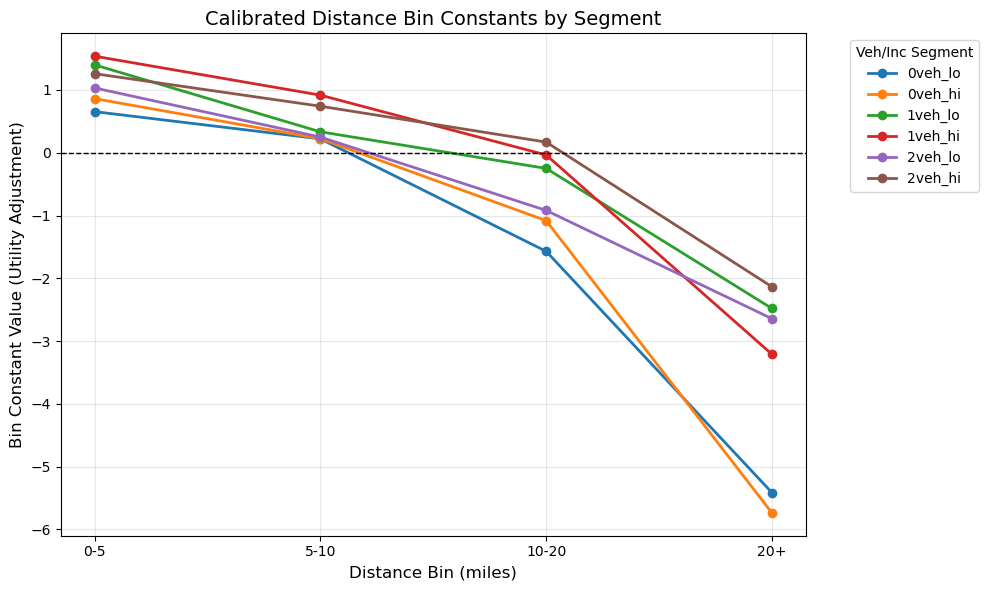

In [290]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the extracted data from the calibrated .block file
data = {
    "Bin": ["0-5", "5-10", "10-20", "20+"],
    "0veh_lo": [0.654829, 0.221132, -1.570629, -5.413851],
    "0veh_hi": [0.862158, 0.222730, -1.081346, -5.736178],
    "1veh_lo": [1.399584, 0.333365, -0.249304, -2.480418],
    "1veh_hi": [1.538234, 0.917138, -0.035432, -3.210064],
    "2veh_lo": [1.032024, 0.249493, -0.918710, -2.642988],
    "2veh_hi": [1.259522, 0.741158, 0.169612, -2.134993],
}

df = pd.DataFrame(data)

# Create the plot
plt.figure(figsize=(10, 6))
for col in df.columns[1:]:
    plt.plot(df["Bin"], df[col], marker="o", linewidth=2, label=col)

plt.title("Calibrated Distance Bin Constants by Segment", fontsize=14)
plt.xlabel("Distance Bin (miles)", fontsize=12)
plt.ylabel("Bin Constant Value (Utility Adjustment)", fontsize=12)

# Add a zero-line for reference
plt.axhline(0, color="black", linewidth=1, linestyle="--")

# Formatting
plt.legend(title="Veh/Inc Segment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save or show
# plt.savefig('distance_bin_constants.png')
plt.show()


# Results


## Calibrated Distance Coefficients

Below are the results if we chose to use the calibrated distance coefficients:

- distcal_0veh_lo = 0.102887
- distcal_0veh_hi = 0.079243
- distcal_1veh_lo = 0.024514
- distcal_1veh_hi = 0.035168
- distcal_2veh_lo = 0.051149
- distcal_2veh_hi = 0.003813


## Calibrate Distance Constants (Binned)

Below are the results if we chose to use the calibrated distance constants (binned):

- "Bin": ["0-5", "5-10", "10-20", "20+"],
- "0veh_lo": [0.727467, 0.215623, -1.679320, -5.621812],
- "0veh_hi": [0.803398, 0.185248, -0.957187, -5.670378],
- "1veh_lo": [1.526813, 0.344729, -0.338823, -2.560785],
- "1veh_hi": [1.471602, 0.922164, -0.001862, -3.206758],
- "2veh_lo": [1.158591, 0.265947, -1.006373, -2.807930],
- "2veh_hi": [1.242963, 0.774615, 0.193064 , -2.154921],
